In [1]:
import pandas as pd
df_origin = pd.read_csv(
    "comptages-routiers-permanents.csv", 
    #encoding = "latin-1",
    #nrows=10, 
    usecols=["Identifiant arc", "Date et heure de comptage", "Débit horaire","Taux d'occupation","Libelle", "geo_point_2d"],
    sep=';'
)
df = df_origin.head(30000)
df.head()


,Identifiant arc,Libelle,Date et heure de comptage,Débit horaire,Taux d'occupation,geo_point_2d
0,5325,PE_Reuilly,2024-10-04T21:00:00+02:00,5955.0,18.70000,"48.83194119399435, 2.4051573651790856"
1,829,Bd_Gal_de_Gaulle (le_Kremlin),2024-11-03T14:00:00+01:00,NaN,24.60056,"48.815888020936654, 2.3587275983847618"
2,4010,Av_de_Clichy,2024-12-04T14:00:00+01:00,223.0,13.72667,"48.89143424973461, 2.3188079239898496"
3,1067,Quai_d'Issy,2025-01-11T19:00:00+01:00,769.0,4.43000,"48.839727155124635, 2.2702033361716216"
4,5460,SI_Passy,2025-02-18T22:00:00+01:00,NaN,NaN,"48.85791852282797, 2.26121220748304"


我们需要分析的包括：
是周几
是否是法国的公共假日或大型活动
是哪个月
是否是周末
是否是学生假日
是否是假日前（包括周末）
是否是假日后（包括周末）
属于哪个季节

Les facteurs que nous devons analyser sont les suivants :
Le jour de la semaine
S'il s'agit d'un jour férié français ou d'un événement majeur
Est-ce un jour férié scolaire ?
Le mois
S'il s'agit d'un week-end
S'il s'agit d'une période précédant un jour férié (week-ends compris)
S'il s'agit d'une période suivant un jour férié (week-ends compris)
La saison

In [2]:
import holidays

# 法国公共假日 jour fériés en France
fr_holidays = holidays.France()
print(fr_holidays)

{'country': FR, 'expand': True, 'language': None, 'market': None, 'observed': True, 'subdiv': None, 'years': set()}


In [3]:
import pandas as pd

MAJOR_EVENTS_PARIS_2025 = {
    "paris_marathon_2025": {"start": "2025-04-06", "end": "2025-04-06"},
    "paris_marathon_2026": {"start": "2026-04-12", "end": "2026-04-12"},
    "french_open": {
        "start": "2025-05-25",
        "end": "2025-06-08"
    },
    "fete_musique": {
        "start": "2025-06-21",
        "end": "2025-06-21"
    },
    "tour_de_france_final": {
        "start": "2025-07-27",
        "end": "2025-07-27"
    }
}

school_holidays_zone_c = [
    ("2024-10-19", "2024-11-03"),
    ("2024-12-21", "2025-01-05"),
    # Vacances d'hiver
    ("2025-02-15", "2025-03-02"),
    # Vacances de printemps
    ("2025-04-12", "2025-04-27"),
    # Vacances d'été
    ("2025-07-05", "2025-08-31"),
    # Vacances de la Toussaint
    ("2025-10-18", "2025-11-02"),
    # Vacances de Noël
    ("2025-12-20", "2026-01-04"),
    ("2026-02-21", "2026-03-08")
]


In [4]:
import pandas as pd
#确保格式  Vérifiez le format
df['Date et heure de comptage'] = pd.to_datetime(
    df['Date et heure de comptage'],
    errors='coerce',  # 遇到无法解析的变成 NaT
    utc=True           # 带时区时间统一转 UTC
)
#获取日期  Date d'acquisition
n_before = len(df)
df = df.dropna(subset=['Date et heure de comptage']).copy()
n_after = len(df)
df["date"] = df["Date et heure de comptage"].dt.date
print(f"Nombre de lignes avant suppression: {n_before}")
print(f"Nombre de lignes supprimées: {n_after}")
# 判断是否公共假日  Vérifiez si c'est un jour férié
df["est_jour_ferie"] = df["date"].apply( lambda d: 1 if d in fr_holidays else 0
)

# 判断是否是大型活动日 Vérifiez s'il s'agit d'un jour d'événement majeur
def is_major_event(date, events):
    for event, period in events.items():
        start = pd.to_datetime(period["start"]).date()
        end = pd.to_datetime(period["end"]).date()
        if start <= date <= end:
            return 1
    return 0
df["est_evenement_majeur"] = df["date"].apply(
    lambda d: is_major_event(d, MAJOR_EVENTS_PARIS_2025)
)

# 判断是否是学生假日 Vérifiez s'il s'agit de vacances scolaires
def is_school_holiday(date, holidays):
    for start_str, end_str in holidays:
        start = pd.to_datetime(start_str).date()
        end = pd.to_datetime(end_str).date()
        if start <= date <= end:
            return 1
    return 0
df['est_vacances_scolaires'] = df['date'].apply(
    lambda d: is_school_holiday(d, school_holidays_zone_c)
)
#判断是否是周末 Vérifiez si c'est weekend
df["est_weekend"] = df["Date et heure de comptage"].dt.weekday >= 5

#判断是否是（假期或大型活动日或周末）的前后一天
#Vérifiez s'il s'agit du jour avant ou après (jour férié, événement majeur ou week-end)
def generate_day_before_after(df, column_name):
    
    # 获取该事件的所有日期 Obtenez toutes les dates de l'événement
    event_dates = set(df.loc[df[column_name], 'date'])
    #  day before
    df[f'{column_name}_day_before'] = df['date'].apply(lambda d: (d + pd.Timedelta(days=1)) in event_dates)
    #  day after
    df[f'{column_name}_day_after'] = df['date'].apply(lambda d: (d - pd.Timedelta(days=1)) in event_dates)
    #  int 0/1
    df[f'{column_name}_day_before'] = df[f'{column_name}_day_before'].astype(int)
    df[f'{column_name}_day_after'] = df[f'{column_name}_day_after'].astype(int)

generate_day_before_after(df, 'est_weekend')
generate_day_before_after(df, 'est_jour_ferie')
generate_day_before_after(df, 'est_evenement_majeur')
generate_day_before_after(df, 'est_vacances_scolaires')

#获取周几，月份以及季节特征 Récupérer le jour de la semaine, le mois et les caractéristiques saisonnières
df["weekday"] = df["Date et heure de comptage"].dt.weekday
df["mois"] = df["Date et heure de comptage"].dt.month
def get_saison(month):
    if month in [12, 1, 2]:
        return "hiver"
    elif month in [3, 4, 5]:
        return "printemps"
    elif month in [6, 7, 8]:
        return "été"
    else:
        return "automne"

df["saison"] = df["mois"].apply(get_saison)

Nombre de lignes avant suppression: 30000
Nombre de lignes supprimées: 30000


C:\Users\14567\AppData\Local\Temp\ipykernel_34952\3378513458.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date et heure de comptage'] = pd.to_datetime(


In [5]:

df.head()

,Identifiant arc,Libelle,Date et heure de comptage,Débit horaire,Taux d'occupation,geo_point_2d,date,est_jour_ferie,est_evenement_majeur,est_vacances_scolaires,...,est_weekend_day_after,est_jour_ferie_day_before,est_jour_ferie_day_after,est_evenement_majeur_day_before,est_evenement_majeur_day_after,est_vacances_scolaires_day_before,est_vacances_scolaires_day_after,weekday,mois,saison
0,5325,PE_Reuilly,2024-10-04 19:00:00+00:00,5955.0,18.70000,"48.83194119399435, 2.4051573651790856",2024-10-04,0,0,0,...,0,0,0,0,0,0,0,4,10,automne
1,829,Bd_Gal_de_Gaulle (le_Kremlin),2024-11-03 13:00:00+00:00,NaN,24.60056,"48.815888020936654, 2.3587275983847618",2024-11-03,0,0,1,...,0,0,0,0,0,0,0,6,11,automne
2,4010,Av_de_Clichy,2024-12-04 13:00:00+00:00,223.0,13.72667,"48.89143424973461, 2.3188079239898496",2024-12-04,0,0,0,...,0,0,0,0,0,0,0,2,12,hiver
3,1067,Quai_d'Issy,2025-01-11 18:00:00+00:00,769.0,4.43000,"48.839727155124635, 2.2702033361716216",2025-01-11,0,0,0,...,0,0,0,0,0,0,0,5,1,hiver
4,5460,SI_Passy,2025-02-18 21:00:00+00:00,NaN,NaN,"48.85791852282797, 2.26121220748304",2025-02-18,0,0,1,...,0,0,0,0,0,0,0,1,2,hiver


In [8]:
summary_weekend = (
    df
    .groupby('est_weekend')
    .agg(
        n=('Débit horaire', 'count'),
        debit_mean=('Débit horaire', 'mean'),
        debit_median=('Débit horaire', 'median'),
        debit_p25=('Débit horaire', lambda x: x.quantile(0.25)),
        debit_p75=('Débit horaire', lambda x: x.quantile(0.75)),
        occupation_mean=('Taux d\'occupation', 'mean')
    )
    .reset_index()
)
summary_weekend


,est_weekend,n,debit_mean,debit_median,debit_p25,debit_p75,occupation_mean
0,False,12077,642.023913,320.0,175.0,561.00,8.441677
1,True,3360,774.043065,344.5,176.0,566.25,7.800439


In [ ]:
import pandas as pd
import copy

# 深拷贝 df
df_time = copy.deepcopy(df)

# 强制转换为 datetime64[ns]，忽略原有 dtype
df_time['Date et heure de comptage'] = pd.to_datetime(
    df_time['Date et heure de comptage'],
    errors='coerce',  # 遇到无法解析的变成 NaT
    utc=True           # 带时区时间统一转 UTC
)

# 去掉时区（如果只分析本地小时/天/月）
df_time['Date et heure de comptage'] = df_time['Date et heure de comptage'].dt.tz_localize(None)

# 现在就可以安全使用 .dt 了
df_time['hour'] = df_time['Date et heure de comptage'].dt.hour
df_time['day'] = df_time['Date et heure de comptage'].dt.day
df_time['month'] = df_time['Date et heure de comptage'].dt.month
df_time['date'] = df_time['Date et heure de comptage'].dt.date


# 查看前几行
df_time.head()


,Identifiant arc,Libelle,Date et heure de comptage,Débit horaire,Taux d'occupation,hour,day,month,date
0,5325,PE_Reuilly,2024-10-04 19:00:00,5955.0,18.70000,19,4,10,2024-10-04
1,829,Bd_Gal_de_Gaulle (le_Kremlin),2024-11-03 13:00:00,NaN,24.60056,13,3,11,2024-11-03
2,4010,Av_de_Clichy,2024-12-04 13:00:00,223.0,13.72667,13,4,12,2024-12-04
3,1067,Quai_d'Issy,2025-01-11 18:00:00,769.0,4.43000,18,11,1,2025-01-11
4,5460,SI_Passy,2025-02-18 21:00:00,NaN,NaN,21,18,2,2025-02-18


In [ ]:
'''空值概览'''
df[['Débit horaire', 'Taux d\'occupation']].isna().mean() * 100


Débit horaire        48.808299
Taux d'occupation    46.427848
dtype: float64

In [ ]:
'''第三步：按时间维度分析空值比例'''
hourly_null = df_time.groupby('hour')[['Débit horaire', 'Taux d\'occupation']].apply(lambda x: x.isna().mean() * 100)
print(hourly_null)
daily_null = df_time.groupby('date')[['Débit horaire', 'Taux d\'occupation']].apply(lambda x: x.isna().mean() * 100)
print(daily_null)
monthly_null = df_time.groupby('month')[['Débit horaire', 'Taux d\'occupation']].apply(lambda x: x.isna().mean() * 100)
print(monthly_null)


      Débit horaire  Taux d'occupation
hour                                  
0         48.488741          46.083281
1         48.628187          46.220916
2         48.557511          46.154074
3         48.527673          46.109499
4         48.584798          46.176725
5         48.581582          46.205094
6         48.840362          46.473352
7         48.789394          46.404497
8         48.993880          46.586437
9         49.535020          47.161189
10        49.528841          47.171293
11        49.835626          47.489354
12        49.230943          46.890231
13        49.088470          46.742284
14        48.927763          46.560844
15        48.890059          46.523324
16        48.648441          46.259637
17        48.597861          46.225824
18        48.625828          46.236356
19        48.625365          46.244333
20        48.455993          46.087298
21        48.454602          46.072828
22        48.466701          46.091758
23        48.483261      

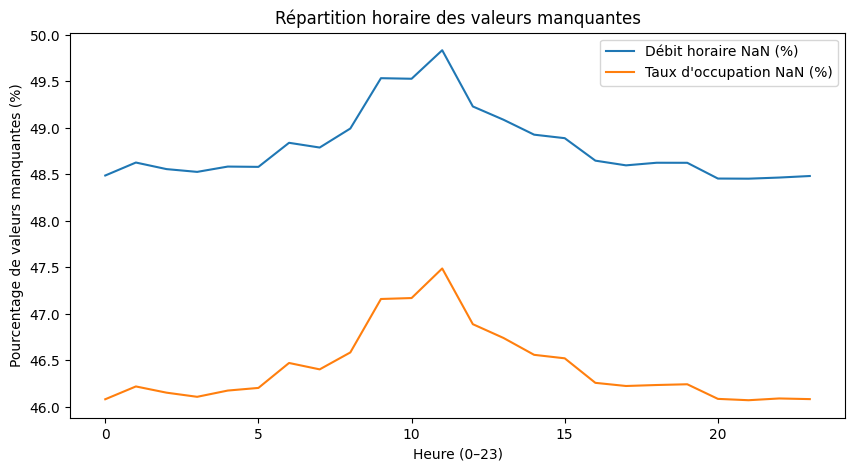

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(hourly_null.index, hourly_null['Débit horaire'], label="Débit horaire NaN (%)")
plt.plot(hourly_null.index, hourly_null['Taux d\'occupation'], label="Taux d'occupation NaN (%)")
plt.xlabel("Heure (0–23)")
plt.ylabel("Pourcentage de valeurs manquantes (%)")
plt.title("Répartition horaire des valeurs manquantes")
plt.legend()
plt.show()


In [ ]:
road_null = (
    df.groupby('Identifiant arc')[['Débit horaire', 'Taux d\'occupation']]
    .apply(lambda x: x.isna().mean() * 100)
    .sort_values(by='Débit horaire', ascending=False)
)

print(road_null.head(10))


                 Débit horaire  Taux d'occupation
Identifiant arc                                  
7274                     100.0         100.000000
1                        100.0          76.342108
2                        100.0           9.667778
3                        100.0         100.000000
4                        100.0           9.529831
7052                     100.0          99.977009
7026                     100.0         100.000000
7025                     100.0         100.000000
7024                     100.0         100.000000
7023                     100.0         100.000000


In [ ]:
import pandas as pd

# 假设 df_time 已经解析好时间列
# 先统计每条道路（Identifiant arc） Taux d'occupation 空值的比例
na_ratio = df_time.groupby('Identifiant arc')['Taux d\'occupation'].apply(lambda x: x.isna().mean())

# 找出空值比例 <= 0.8 的道路
valid_arcs = na_ratio[na_ratio <= 0.8].index

# 筛选 df_time，只保留这些道路
df_filtered = df_time[df_time['Identifiant arc'].isin(valid_arcs)]

# 查看前几行
df_filtered.head()

# 检查剩下的道路数量和空值情况
print("原始道路数量:", df_time['Libelle'].nunique())
print("剩余道路数量:", df_filtered['Libelle'].nunique())
print("空值比例:\n", df_filtered['Taux d\'occupation'].isna().mean())
print("流量空值比例:\n", df_filtered['Débit horaire'].isna().mean())


原始道路数量: 893
剩余道路数量: 582
空值比例:
 0.11846979526884353
流量空值比例:
 0.3087784731360488


In [ ]:
import pandas as pd

# 假设 df_time 已经解析好时间列
# 先统计每条道路（Identifiant arc） Taux d'occupation 空值的比例
na_ratio = df_time.groupby('Identifiant arc')['Taux d\'occupation'].apply(lambda x: x.isna().mean())

# 找出空值比例 <= 0.8 的道路
valid_arcs = na_ratio[na_ratio <= 0.8].index

# 筛选 df_time，只保留这些道路
df_filtered = df_time[df_time['Identifiant arc'].isin(valid_arcs)]

# 查看前几行
df_filtered.head()

# 检查剩下的道路数量和空值情况
print("原始道路数量:", df_time['Identifiant arc'].nunique())
print("剩余道路数量:", df_filtered['Identifiant arc'].nunique())
print("空值比例:\n", df_filtered['Taux d\'occupation'].isna().mean())
print("流量空值比例:\n", df_filtered['Débit horaire'].isna().mean())


原始道路数量: 2985
剩余道路数量: 1804
空值比例:
 0.11846979526884353
流量空值比例:
 0.3087784731360488


In [ ]:
'''第三步：按时间维度分析空值比例'''
hourly_null = df_filtered.groupby('hour')[['Débit horaire', 'Taux d\'occupation']].apply(lambda x: x.isna().mean() * 100)
print(hourly_null)
daily_null = df_filtered.groupby('date')[['Débit horaire', 'Taux d\'occupation']].apply(lambda x: x.isna().mean() * 100)
print(daily_null)
monthly_null = df_filtered.groupby('month')[['Débit horaire', 'Taux d\'occupation']].apply(lambda x: x.isna().mean() * 100)
print(monthly_null)


      Débit horaire  Taux d'occupation
hour                                  
0         30.439489          11.273340
1         30.606291          11.500679
2         30.510860          11.392353
3         30.463829          11.322413
4         30.554696          11.435000
5         30.559247          11.481845
6         30.900689          11.926579
7         30.838748          11.809915
8         31.133217          12.104689
9         31.886709          13.050995
10        31.884155          13.067344
11        32.264008          13.591093
12        31.464694          12.603092
13        31.282643          12.364308
14        31.077172          12.066384
15        31.027396          12.009813
16        30.659010          11.570286
17        30.585588          11.512599
18        30.626475          11.530059
19        30.628468          11.544777
20        30.398041          11.283382
21        30.394362          11.261305
22        30.420948          11.311267
23        30.444159      

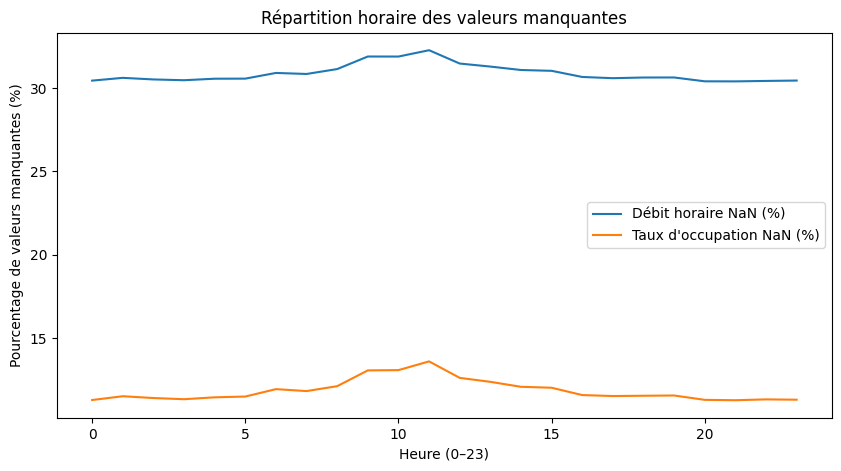

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(hourly_null.index, hourly_null['Débit horaire'], label="Débit horaire NaN (%)")
plt.plot(hourly_null.index, hourly_null['Taux d\'occupation'], label="Taux d'occupation NaN (%)")
plt.xlabel("Heure (0–23)")
plt.ylabel("Pourcentage de valeurs manquantes (%)")
plt.title("Répartition horaire des valeurs manquantes")
plt.legend()
plt.show()


In [ ]:
import pandas as pd
import numpy as np

def consecutive_non_na_lengths(series):
    is_valid = ~series.isna()  # 非空为 True
    lengths = []
    count = 0
    for val in is_valid:
        if val:
            count += 1
        else:
            if count > 0:
                lengths.append(count)
                count = 0
    if count > 0:
        lengths.append(count)
    return lengths

# 按道路分别统计 Débit horaire 和 Taux d'occupation
df_sorted = df_time.sort_values(['Identifiant arc', 'Date et heure de comptage'])

non_na_lengths_debit = df_sorted.groupby('Identifiant arc')['Débit horaire'].apply(consecutive_non_na_lengths)
non_na_lengths_occup = df_sorted.groupby('Identifiant arc')['Taux d\'occupation'].apply(consecutive_non_na_lengths)

# 合并所有道路，查看分布
all_lengths_debit = np.concatenate(non_na_lengths_debit.values)
all_lengths_occup = np.concatenate(non_na_lengths_occup.values)

print("Débit horaire 连续非空值长度描述统计：")
print(pd.Series(all_lengths_debit).describe())

print("Taux d'occupation 连续非空值长度描述统计：")
print(pd.Series(all_lengths_occup).describe())


Débit horaire 连续非空值长度描述统计：
count    170559.000000
mean         77.813120
std         142.958684
min           1.000000
25%           4.000000
50%          21.000000
75%          91.000000
max        1771.000000
dtype: float64
Taux d'occupation 连续非空值长度描述统计：
count    181775.000000
mean         76.406948
std         140.772918
min           1.000000
25%           4.000000
50%          20.000000
75%          89.000000
max        1771.000000
dtype: float64


In [ ]:
df_filtered.head()label

,Identifiant arc,Libelle,Date et heure de comptage,Débit horaire,Taux d'occupation,hour,day,month,date
0,5325,PE_Reuilly,2024-10-04 19:00:00,5955.0,18.70000,19,4,10,2024-10-04
1,829,Bd_Gal_de_Gaulle (le_Kremlin),2024-11-03 13:00:00,NaN,24.60056,13,3,11,2024-11-03
2,4010,Av_de_Clichy,2024-12-04 13:00:00,223.0,13.72667,13,4,12,2024-12-04
3,1067,Quai_d'Issy,2025-01-11 18:00:00,769.0,4.43000,18,11,1,2025-01-11
5,1505,Bd_Serurier,2025-03-01 15:00:00,NaN,13.19611,15,1,3,2025-03-01


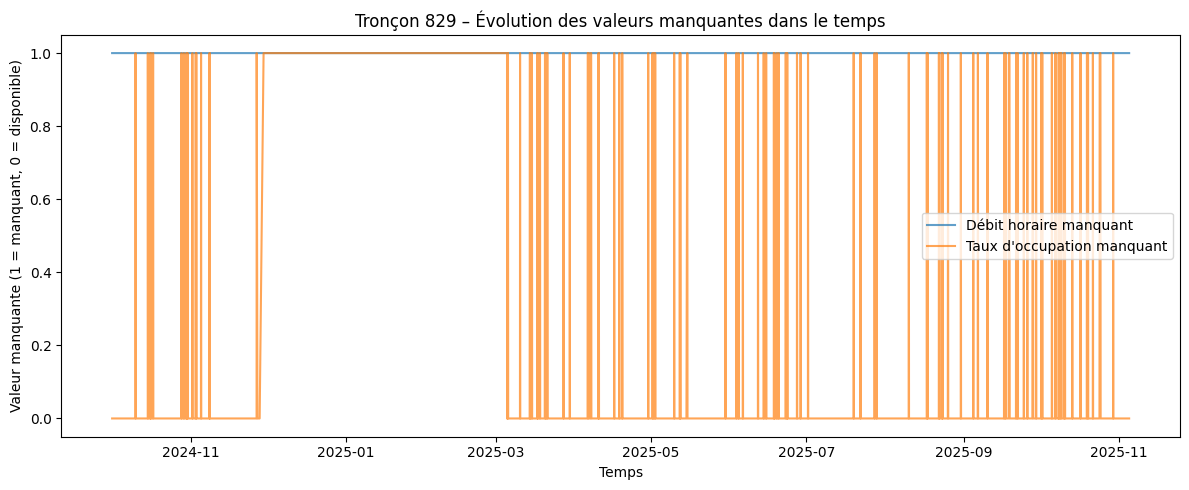

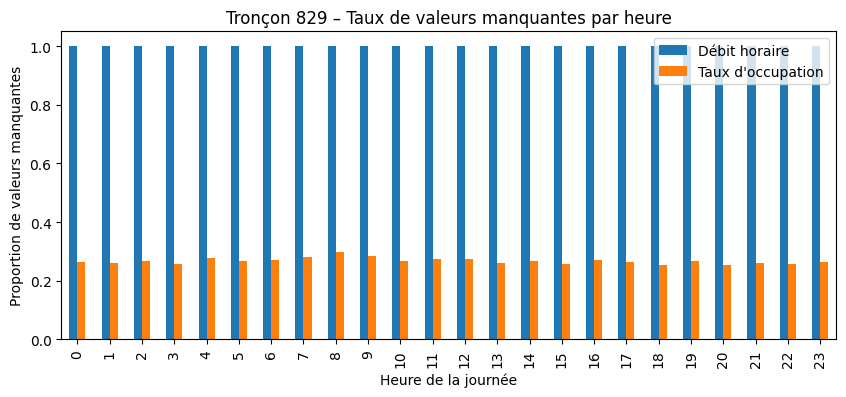

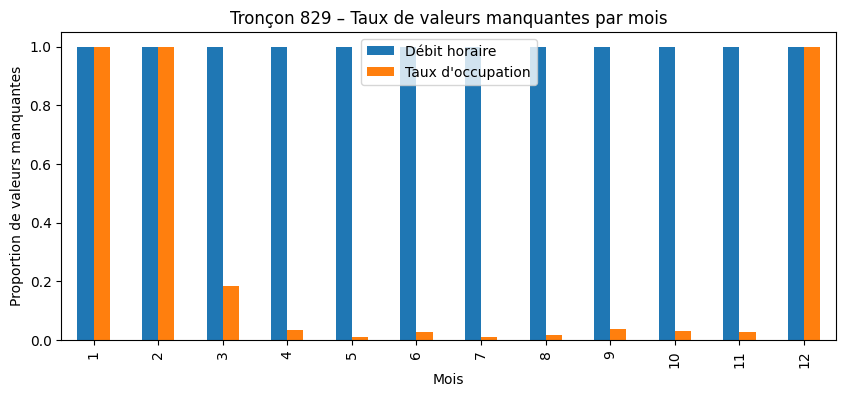

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 选择一条道路
arc_id = 829
g = df_time[df_time['Identifiant arc'] == arc_id].copy()

# 按时间排序
g = g.sort_values('Date et heure de comptage')

# 创建空值标志列
g['isna_Débit'] = g['Débit horaire'].isna().astype(int)
g['isna_Taux'] = g['Taux d\'occupation'].isna().astype(int)

# ==== 图1：空值随时间变化 ====
plt.figure(figsize=(12, 5))
plt.plot(g['Date et heure de comptage'], g['isna_Débit'], label='Débit horaire manquant', alpha=0.7)
plt.plot(g['Date et heure de comptage'], g['isna_Taux'], label='Taux d\'occupation manquant', alpha=0.7)
plt.xlabel('Temps')
plt.ylabel('Valeur manquante (1 = manquant, 0 = disponible)')
plt.title(f'Tronçon {arc_id} – Évolution des valeurs manquantes dans le temps')
plt.legend()
plt.tight_layout()
plt.show()

# ==== 图2：按小时统计空值率 ====
g['heure'] = g['Date et heure de comptage'].dt.hour
taux_horaire = g.groupby('heure')[['Débit horaire', 'Taux d\'occupation']].apply(lambda x: x.isna().mean())

taux_horaire.plot(kind='bar', figsize=(10,4), title=f'Tronçon {arc_id} – Taux de valeurs manquantes par heure')
plt.ylabel('Proportion de valeurs manquantes')
plt.xlabel('Heure de la journée')
plt.show()

# ==== 图3：按月份统计空值率 ====
g['mois'] = g['Date et heure de comptage'].dt.month
taux_mensuel = g.groupby('mois')[['Débit horaire', 'Taux d\'occupation']].apply(lambda x: x.isna().mean())

taux_mensuel.plot(kind='bar', figsize=(10,4), title=f'Tronçon {arc_id} – Taux de valeurs manquantes par mois')
plt.ylabel('Proportion de valeurs manquantes')
plt.xlabel('Mois')
plt.show()
